# Notebook 20 - Debug current Python alpha and choose the next correction

This notebook answers the question from the graph in notebook 19:

**Is the current Python alpha mainly a sign flip, or is the estimator itself different from MATLAB?**

We will keep the production code untouched here. The notebook compares:

1. Current Python alpha from the selected Frangi/Hough line segment.
2. `abs(current Python alpha)`, as a simple "what if this was only a sign convention issue" check.
3. MATLAB-style `dohough + weighted_median` applied to the current Python Frangi mask.

If `abs(alpha)` is still poor but MATLAB-style `dohough` is good, the next correction should be replacing the segment-based alpha estimator, then improving the mask.

## Assumptions and information that would help

I can run this with the information currently in the project. The most useful extra file later would be the exact MATLAB `parms.mat` or a screenshot/export of the UltraTimTrack parameter settings used to generate `slow_low_01_DOWN_tracked_Q=001.mat`. Mask parity depends on those values.

Useful confirmations:

- Was MATLAB run on the same full-resolution video as `data/raw/UltraTimTrack_test.mp4`?
- Were default TimTrack fascicle parameters used: angle range `[8, 80]`, `npeaks = 10`, `thetares = 1`, `rhores = 1`?
- Was the MATLAB run using the same approximate fascicle ROI as `data/rois/UltraTimTrack_test_rois.json`?

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

%load_ext autoreload
%autoreload 2

current = Path.cwd()
if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import json
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ultrasound_tracker.legacy.frangi_detector import FrangiDetector
from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_geofeature_arrays,
    load_matlab_result,
)
from ultrasound_tracker.timtrack_hough import DoHoughParams, dohough

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def sin_deg(x):
    return np.sin(np.deg2rad(x))

def signed_line_angle_deg(lines):
    lines = np.asarray(lines, dtype=float)
    dx = lines[:, 2] - lines[:, 0]
    dy = lines[:, 3] - lines[:, 1]
    angle = np.degrees(np.arctan2(-dy, dx))
    angle = angle % 180.0
    angle[angle >= 90.0] -= 180.0
    return angle

def metric_table(named_pairs):
    rows = []
    for name, ref, est in named_pairs:
        row = {"comparison": name}
        row.update(compute_metrics(ref, est))
        rows.append(row)
    return pd.DataFrame(rows)

def paired(a, b):
    n = min(len(a), len(b))
    return np.asarray(a, dtype=float)[:n], np.asarray(b, dtype=float)[:n]

## Load reference and current Python outputs

`matlab_geo["alpha_deg"]` is the target we want to reproduce before thinking about Kalman.

In [3]:
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
PY_TIMTRACK = PROJECT_ROOT / "results" / "timtrack_sequence_features_arrays.npz"
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"
OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

mat = load_matlab_result(MATLAB_RESULT)
matlab_geo = extract_geofeature_arrays(mat)
py_tim = dict(np.load(PY_TIMTRACK, allow_pickle=True))

n = min(len(matlab_geo["alpha_deg"]), len(py_tim["fascicle_angle_deg"]))

matlab_alpha = matlab_geo["alpha_deg"][:n]
matlab_phi = matlab_geo["phi_deg"][:n]
matlab_faslen = matlab_geo["faslen_px"][:n]
matlab_betha = matlab_geo["super_apo_angle_deg"][:n]
matlab_thickness = matlab_geo["muscle_thickness_px"][:n]

py_alpha = np.asarray(py_tim["fascicle_angle_deg"], dtype=float)[:n]
py_phi = np.asarray(py_tim["pennation_angle_deg"], dtype=float)[:n]
py_faslen = np.asarray(py_tim["fascicle_length_px"], dtype=float)[:n]
py_lines = np.asarray(py_tim["fascicle_lines"], dtype=float)[:n]
py_segments = np.asarray(py_tim["fascicle_segments"], dtype=float)[:n]
frames = np.asarray(py_tim["frame"], dtype=int)[:n]

selected_line_angle = signed_line_angle_deg(py_lines)
segment_angle = signed_line_angle_deg(py_segments)

print("n aligned:", n)
print("current Python alpha finite:", np.sum(np.isfinite(py_alpha)), "/", len(py_alpha))
print("current Python alpha negative frames:", np.sum(py_alpha < 0))
print("current Python alpha sign changes:", np.sum(np.diff(np.signbit(py_alpha[np.isfinite(py_alpha)])) != 0))

n aligned: 2666
current Python alpha finite: 2666 / 2666
current Python alpha negative frames: 334
current Python alpha sign changes: 530


## 1. Is this only a sign convention problem?

If the current alpha were only wrong because of a sign flip, `abs(current alpha)` would become close to MATLAB. This is a cheap diagnostic before changing anything.

In [4]:
sign_metrics = metric_table([
    ("current Python alpha", matlab_alpha, py_alpha),
    ("abs(current Python alpha)", matlab_alpha, np.abs(py_alpha)),
    ("current selected-line angle", matlab_alpha, selected_line_angle),
    ("abs(current selected-line angle)", matlab_alpha, np.abs(selected_line_angle)),
    ("current segment angle", matlab_alpha, segment_angle),
    ("abs(current segment angle)", matlab_alpha, np.abs(segment_angle)),
])
sign_metrics

,comparison,n,bias,mae,rmse,corr
0,current Python alpha,2666,-11.390793,11.659603,18.967960,-0.096262
1,abs(current Python alpha),2666,-5.965139,6.327067,8.082938,0.137499
2,current selected-line angle,2666,-11.390792,11.659602,18.967960,-0.096262
3,abs(current selected-line angle),2666,-5.965138,6.327066,8.082938,0.137499
4,current segment angle,2666,-11.390792,11.659602,18.967960,-0.096262
5,abs(current segment angle),2666,-5.965138,6.327066,8.082938,0.137499


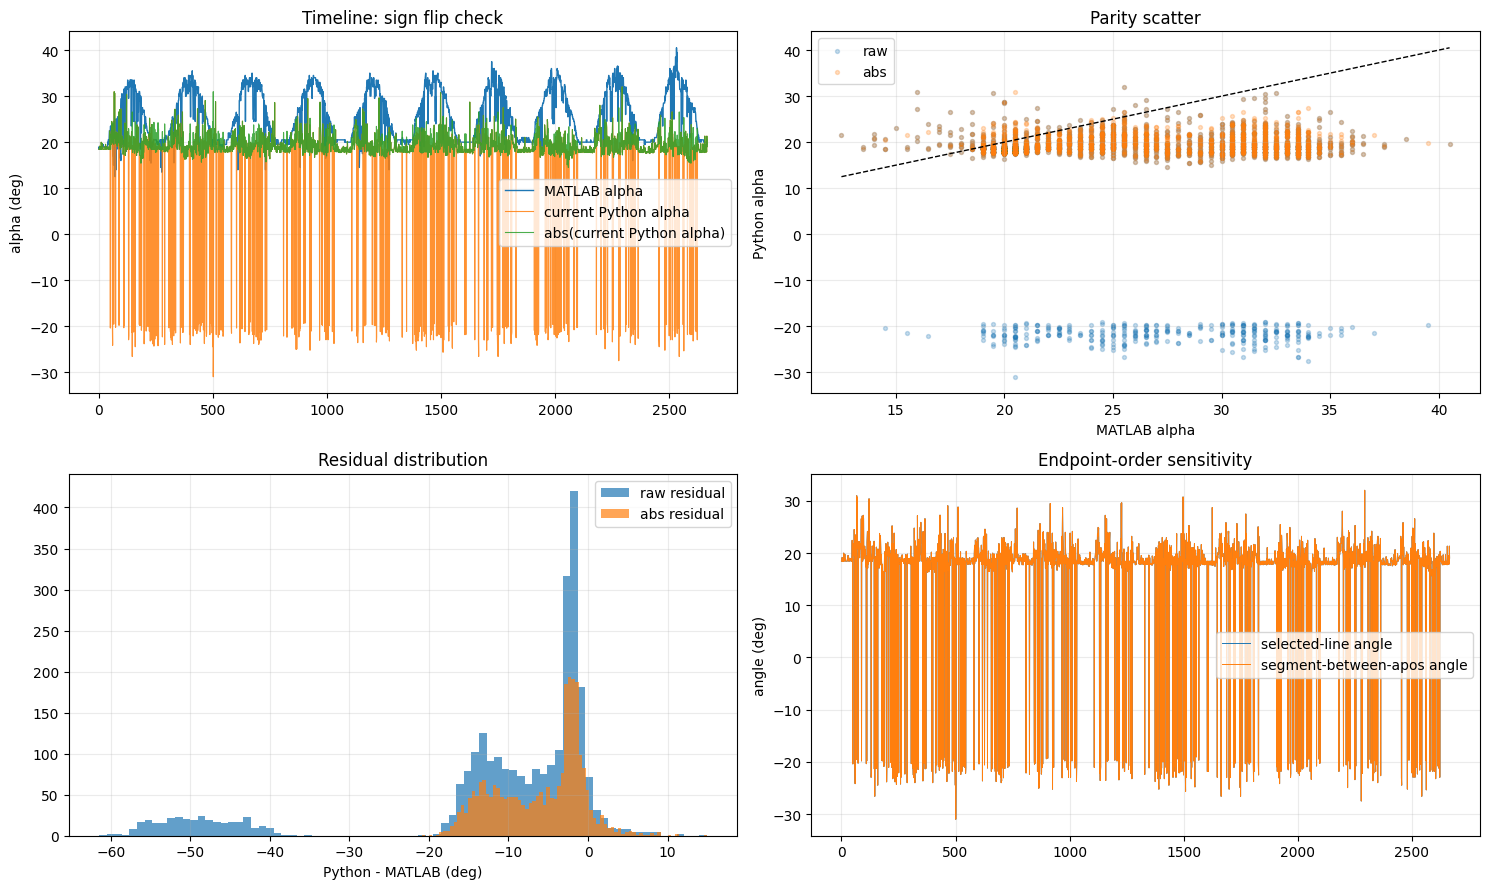

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=False)

axes[0, 0].plot(matlab_alpha, label="MATLAB alpha", linewidth=1)
axes[0, 0].plot(py_alpha, label="current Python alpha", linewidth=0.8, alpha=0.85)
axes[0, 0].plot(np.abs(py_alpha), label="abs(current Python alpha)", linewidth=0.8, alpha=0.85)
axes[0, 0].set_ylabel("alpha (deg)")
axes[0, 0].set_title("Timeline: sign flip check")
axes[0, 0].legend()

axes[0, 1].scatter(matlab_alpha, py_alpha, s=8, alpha=0.25, label="raw")
axes[0, 1].scatter(matlab_alpha, np.abs(py_alpha), s=8, alpha=0.25, label="abs")
lo, hi = np.nanmin(matlab_alpha), np.nanmax(matlab_alpha)
axes[0, 1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0, 1].set_xlabel("MATLAB alpha")
axes[0, 1].set_ylabel("Python alpha")
axes[0, 1].set_title("Parity scatter")
axes[0, 1].legend()

axes[1, 0].hist((py_alpha - matlab_alpha)[np.isfinite(py_alpha - matlab_alpha)], bins=80, alpha=0.7, label="raw residual")
axes[1, 0].hist((np.abs(py_alpha) - matlab_alpha)[np.isfinite(py_alpha)], bins=80, alpha=0.7, label="abs residual")
axes[1, 0].set_xlabel("Python - MATLAB (deg)")
axes[1, 0].set_title("Residual distribution")
axes[1, 0].legend()

axes[1, 1].plot(selected_line_angle, label="selected-line angle", linewidth=0.7)
axes[1, 1].plot(segment_angle, label="segment-between-apos angle", linewidth=0.7)
axes[1, 1].set_ylabel("angle (deg)")
axes[1, 1].set_title("Endpoint-order sensitivity")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 2. What do the sign flips look like in the image?

The arrows below show the current selected line segment direction. The visual line can be similar while the endpoint order changes, which changes the signed angle.

In [6]:
with ROI_PATH.open() as handle:
    rois = json.load(handle)

x_roi, y_roi, w_roi, h_roi = rois["fascicle"]

finite = np.isfinite(py_alpha)
sign_change_candidates = np.where(finite[1:] & finite[:-1] & (np.signbit(py_alpha[1:]) != np.signbit(py_alpha[:-1])))[0] + 1

if len(sign_change_candidates) >= 3:
    example_indices = sign_change_candidates[:3]
else:
    neg = np.where(py_alpha < 0)[0][:2]
    pos = np.where(py_alpha > 0)[0][:2]
    example_indices = np.concatenate([neg, pos])[:4]

print("Example indices:", example_indices)
print("Example frame numbers:", frames[example_indices])

Example indices: [50 51 59]
Example frame numbers: [50 51 59]


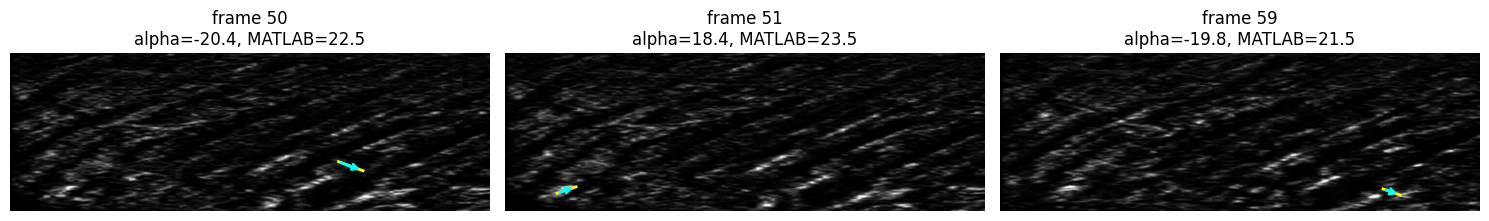

In [7]:
def read_gray_frame(video_path, frame_idx):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok:
        return None
    if frame.ndim == 3:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return frame.copy()

if len(example_indices) > 0:
    fig, axes = plt.subplots(1, len(example_indices), figsize=(5 * len(example_indices), 4))
    if len(example_indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, example_indices):
        gray = read_gray_frame(VIDEO_PATH, frames[idx])
        crop = gray[y_roi : y_roi + h_roi, x_roi : x_roi + w_roi]
        line = py_lines[idx].copy()
        line_local = line - np.array([x_roi, y_roi, x_roi, y_roi], dtype=float)

        ax.imshow(crop, cmap="gray")
        ax.plot([line_local[0], line_local[2]], [line_local[1], line_local[3]], color="yellow", linewidth=2)
        ax.annotate(
            "",
            xy=(line_local[2], line_local[3]),
            xytext=(line_local[0], line_local[1]),
            arrowprops=dict(arrowstyle="->", color="cyan", linewidth=2),
        )
        ax.set_title(
            f"frame {frames[idx]}\nalpha={py_alpha[idx]:.1f}, MATLAB={matlab_alpha[idx]:.1f}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 3. Apply MATLAB-style `dohough` to the current Python mask

This still is not exact MATLAB parity, because the mask comes from the current Python `FrangiDetector` and the user-selected fascicle ROI. But it directly tests whether the current line-selection step is the dominant problem.

The output is cached. Set `RECOMPUTE_PORTED_HOUGH = True` to force a rerun.

In [8]:
PORTED_HOUGH_OUT = OUT_DIR / "notebook20_ported_dohough_current_mask_arrays.npz"
RECOMPUTE_PORTED_HOUGH = False

fas_detector = FrangiDetector(
    sigmas=(1, 2, 4),
    alpha=0.5,
    beta=15.0,
    black_ridges=False,
    threshold=0.08,
    angle_min=10,
    angle_max=70,
    hough_threshold=15,
    min_line_length=25,
    max_line_gap=15,
)

hough_params = DoHoughParams(
    angle_range=(8.0, 80.0),
    thetares=1.0,
    rhores=1.0,
    emask_radius=(h_roi / 2.0, w_roi / 2.0),
    npeaks=10,
    replace_diagonal_bias=True,
)

print("Output:", PORTED_HOUGH_OUT)
print("ROI:", rois["fascicle"])
print("Hough params:", hough_params)

Output: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook20_ported_dohough_current_mask_arrays.npz
ROI: [17, 65, 686, 226]
Hough params: DoHoughParams(houghangles='specified', angle_range=(8.0, 80.0), thetares=1.0, rhores=1.0, emask_radius=(113.0, 343.0), npeaks=10, show=False, replace_diagonal_bias=True)


In [9]:
def compute_ported_hough_sequence():
    alpha = np.full(n, np.nan, dtype=float)
    mask_density = np.full(n, np.nan, dtype=float)
    first_peak_alpha = np.full(n, np.nan, dtype=float)
    first_peak_weight = np.full(n, np.nan, dtype=float)

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    started = time.time()

    for out_idx in range(n):
        ok, frame = cap.read()
        if not ok:
            break

        if frame.ndim == 3:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        else:
            gray = frame.copy()

        crop = gray[y_roi : y_roi + h_roi, x_roi : x_roi + w_roi]
        vesselness = fas_detector.get_vesselness_map(crop)
        binary = vesselness >= fas_detector.threshold
        result = dohough(binary, hough_params)

        alpha[out_idx] = result["alpha"]
        mask_density[out_idx] = np.mean(binary)

        if len(result["alphas"]) > 0:
            first_peak_alpha[out_idx] = result["alphas"][0]
            first_peak_weight[out_idx] = result["weights"][0]

        if (out_idx + 1) % 250 == 0:
            elapsed = time.time() - started
            print(f"{out_idx + 1}/{n} frames, elapsed {elapsed:.1f} s")

    cap.release()
    print(f"Finished in {time.time() - started:.1f} s")
    return alpha, mask_density, first_peak_alpha, first_peak_weight

if PORTED_HOUGH_OUT.exists() and not RECOMPUTE_PORTED_HOUGH:
    cached = np.load(PORTED_HOUGH_OUT, allow_pickle=True)
    ported_alpha = cached["ported_alpha"]
    mask_density = cached["mask_density"]
    first_peak_alpha = cached["first_peak_alpha"]
    first_peak_weight = cached["first_peak_weight"]
    print("Loaded cached ported Hough sequence")
else:
    ported_alpha, mask_density, first_peak_alpha, first_peak_weight = compute_ported_hough_sequence()
    np.savez(
        PORTED_HOUGH_OUT,
        frame=frames,
        ported_alpha=ported_alpha,
        mask_density=mask_density,
        first_peak_alpha=first_peak_alpha,
        first_peak_weight=first_peak_weight,
    )
    print("Saved", PORTED_HOUGH_OUT)

print("Finite ported alpha:", np.sum(np.isfinite(ported_alpha)), "/", len(ported_alpha))

250/2666 frames, elapsed 9.1 s


500/2666 frames, elapsed 18.0 s


750/2666 frames, elapsed 26.6 s


1000/2666 frames, elapsed 35.5 s


1250/2666 frames, elapsed 44.1 s


...

1750/2666 frames, elapsed 61.5 s


2000/2666 frames, elapsed 70.1 s


2250/2666 frames, elapsed 79.9 s


2500/2666 frames, elapsed 89.7 s


Finished in 96.7 s
Saved /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook20_ported_dohough_current_mask_arrays.npz
Finite ported alpha: 2666 / 2666


## 4. Compare current alpha, sign-fixed alpha, and ported Hough alpha

In [10]:
ported_phi_alpha_only = ported_alpha - matlab_betha
ported_faslen_alpha_only = matlab_thickness / sin_deg(ported_phi_alpha_only)

abs_phi_alpha_only = np.abs(py_alpha) - matlab_betha
abs_faslen_alpha_only = matlab_thickness / sin_deg(abs_phi_alpha_only)

comparison_metrics = metric_table([
    ("current Python alpha", matlab_alpha, py_alpha),
    ("abs(current Python alpha)", matlab_alpha, np.abs(py_alpha)),
    ("ported dohough alpha on current mask", matlab_alpha, ported_alpha),
    ("current Python phi", matlab_phi, py_phi),
    ("ported alpha-only phi", matlab_phi, ported_phi_alpha_only),
    ("current Python faslen", matlab_faslen, py_faslen),
    ("abs-alpha-only faslen", matlab_faslen, abs_faslen_alpha_only),
    ("ported alpha-only faslen", matlab_faslen, ported_faslen_alpha_only),
])

comparison_metrics

,comparison,n,bias,mae,rmse,corr
0,current Python alpha,2666,-11.390793,11.659603,18.967960,-0.096262
1,abs(current Python alpha),2666,-5.965139,6.327067,8.082938,0.137499
2,ported dohough alpha on current mask,2666,2.319392,2.526819,3.537244,0.866061
3,current Python phi,2666,-10.682523,10.973685,18.415540,-0.083700
4,ported alpha-only phi,2666,2.319392,2.526819,3.537244,0.854832
5,current Python faslen,2666,146.038386,155.143503,183.660677,0.373588
6,abs-alpha-only faslen,2666,143.148548,154.905338,188.285014,0.227755
7,ported alpha-only faslen,2666,-54.010967,57.037952,84.701557,0.845229


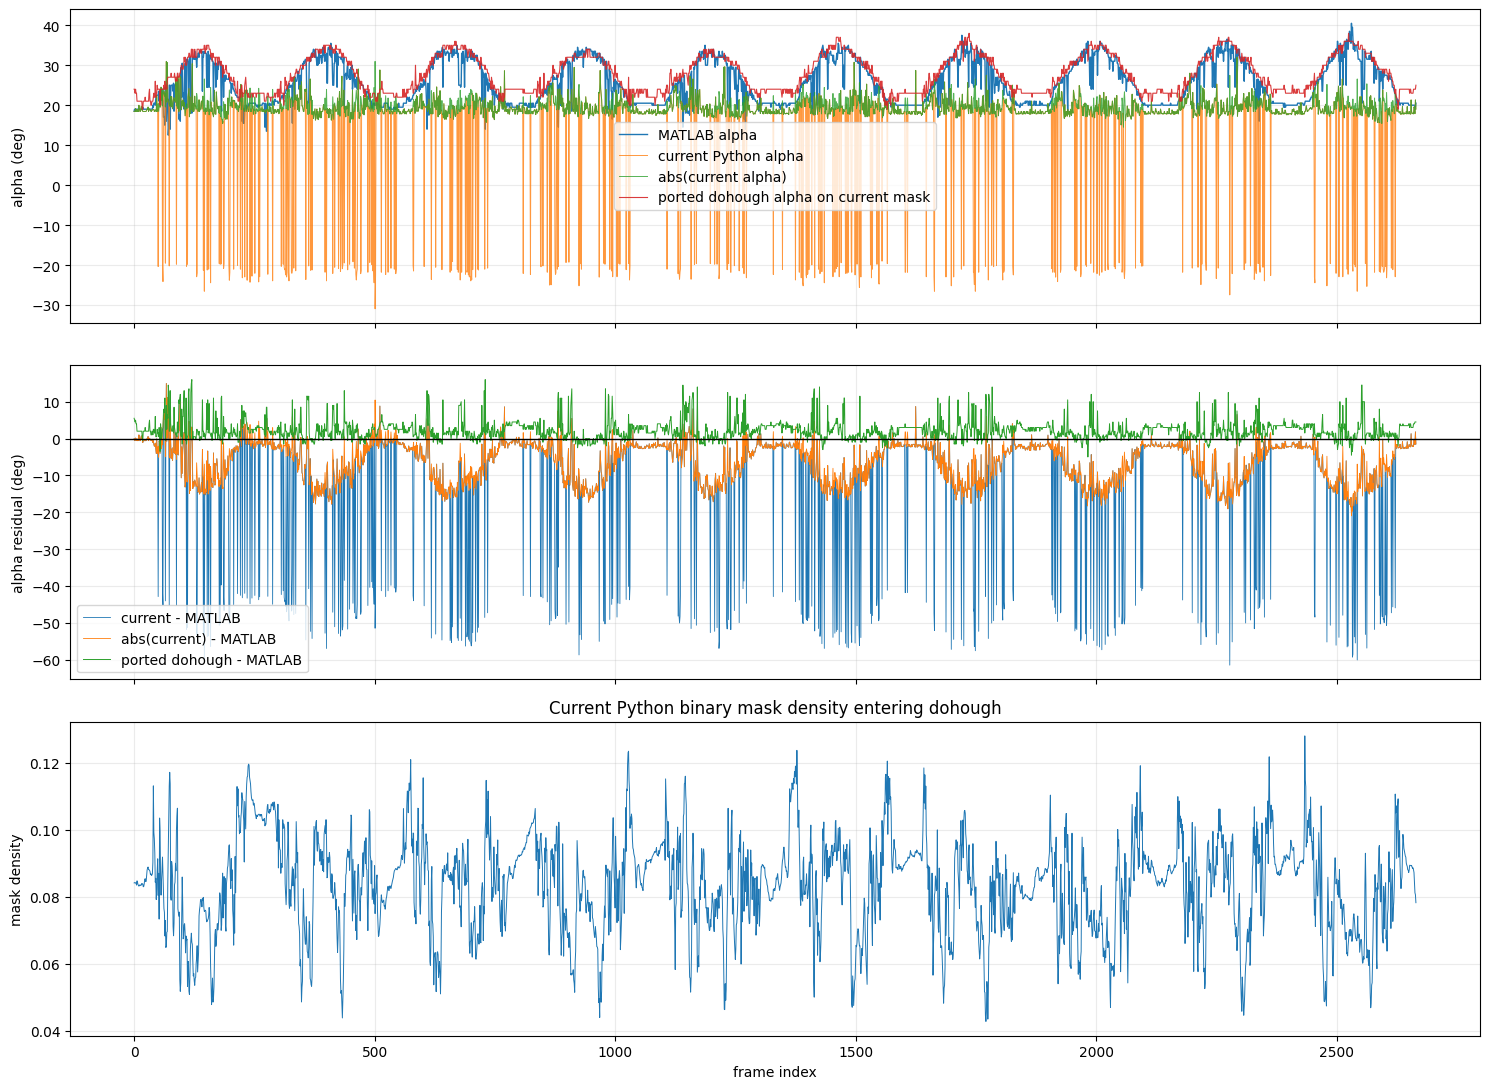

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

axes[0].plot(matlab_alpha, label="MATLAB alpha", linewidth=1.0)
axes[0].plot(py_alpha, label="current Python alpha", linewidth=0.7, alpha=0.8)
axes[0].plot(np.abs(py_alpha), label="abs(current alpha)", linewidth=0.7, alpha=0.8)
axes[0].plot(ported_alpha, label="ported dohough alpha on current mask", linewidth=0.8, alpha=0.9)
axes[0].set_ylabel("alpha (deg)")
axes[0].legend()

axes[1].plot(py_alpha - matlab_alpha, label="current - MATLAB", linewidth=0.6)
axes[1].plot(np.abs(py_alpha) - matlab_alpha, label="abs(current) - MATLAB", linewidth=0.6)
axes[1].plot(ported_alpha - matlab_alpha, label="ported dohough - MATLAB", linewidth=0.7)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("alpha residual (deg)")
axes[1].legend()

axes[2].plot(mask_density, linewidth=0.7)
axes[2].set_ylabel("mask density")
axes[2].set_xlabel("frame index")
axes[2].set_title("Current Python binary mask density entering dohough")

plt.tight_layout()
plt.show()

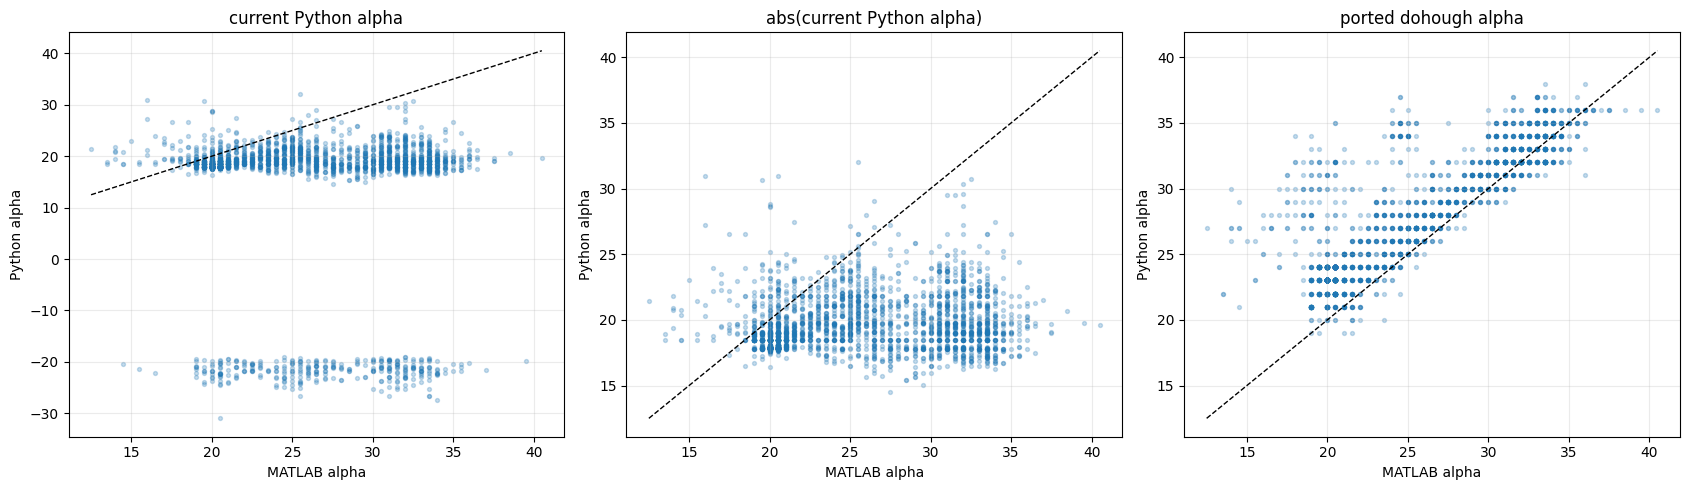

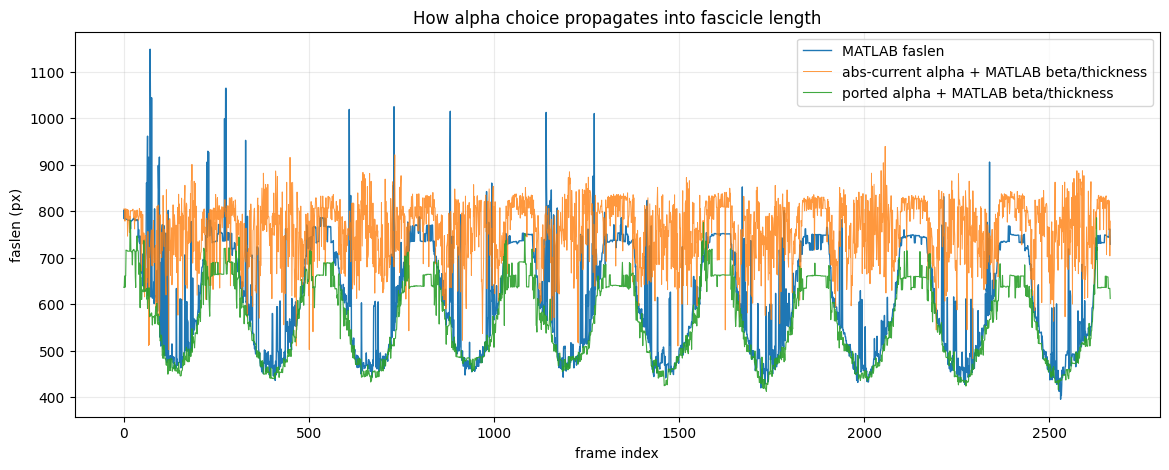

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, values, title in [
    (axes[0], py_alpha, "current Python alpha"),
    (axes[1], np.abs(py_alpha), "abs(current Python alpha)"),
    (axes[2], ported_alpha, "ported dohough alpha"),
]:
    ax.scatter(matlab_alpha, values, s=8, alpha=0.25)
    lo = np.nanmin(matlab_alpha)
    hi = np.nanmax(matlab_alpha)
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_xlabel("MATLAB alpha")
    ax.set_ylabel("Python alpha")
    ax.set_title(title)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(matlab_faslen, label="MATLAB faslen", linewidth=1)
plt.plot(abs_faslen_alpha_only, label="abs-current alpha + MATLAB beta/thickness", linewidth=0.7, alpha=0.8)
plt.plot(ported_faslen_alpha_only, label="ported alpha + MATLAB beta/thickness", linewidth=0.8, alpha=0.9)
plt.ylabel("faslen (px)")
plt.xlabel("frame index")
plt.title("How alpha choice propagates into fascicle length")
plt.legend()
plt.show()

## 5. Interpretation

Read this cell after running the notebook. The expected decision logic is:

- If `abs(current Python alpha)` is still much worse than MATLAB-style `dohough`, the problem is not only sign convention.
- If MATLAB-style `dohough` is much closer, the current segment-selection alpha should be replaced by the Hough weighted-median alpha.
- Any remaining error after that points upstream to the mask: MATLAB `filter_usimage.m`, aponeurosis subtraction, and `get_fasMask.m`.

In [13]:
comparison_metrics.to_csv(
    OUT_DIR / "notebook20_alpha_debug_metrics.csv",
    index=False,
)
sign_metrics.to_csv(
    OUT_DIR / "notebook20_sign_diagnostic_metrics.csv",
    index=False,
)

np.savez(
    OUT_DIR / "notebook20_alpha_debug_arrays.npz",
    frame=frames,
    matlab_alpha=matlab_alpha,
    current_python_alpha=py_alpha,
    abs_current_python_alpha=np.abs(py_alpha),
    selected_line_angle=selected_line_angle,
    segment_angle=segment_angle,
    ported_dohough_alpha=ported_alpha,
    mask_density=mask_density,
    matlab_phi=matlab_phi,
    ported_phi_alpha_only=ported_phi_alpha_only,
    matlab_faslen=matlab_faslen,
    ported_faslen_alpha_only=ported_faslen_alpha_only,
)

display(comparison_metrics)

raw_mae = comparison_metrics.loc[comparison_metrics["comparison"] == "current Python alpha", "mae"].iloc[0]
abs_mae = comparison_metrics.loc[comparison_metrics["comparison"] == "abs(current Python alpha)", "mae"].iloc[0]
ported_mae = comparison_metrics.loc[comparison_metrics["comparison"] == "ported dohough alpha on current mask", "mae"].iloc[0]

print("Decision summary")
print("----------------")
print(f"Raw current alpha MAE:      {raw_mae:.3f} deg")
print(f"Absolute-value alpha MAE:   {abs_mae:.3f} deg")
print(f"Ported dohough alpha MAE:   {ported_mae:.3f} deg")
print()

if ported_mae < abs_mae:
    print("Conclusion: taking abs(alpha) helps with sign but does not solve the estimator mismatch.")
    print("Next correction: use MATLAB-style dohough + weighted_median for alpha, then port the MATLAB mask pipeline.")
else:
    print("Conclusion: sign convention explains most of the current mismatch. Verify endpoint orientation before changing the estimator.")

print()
print("Saved:")
print(" -", OUT_DIR / "notebook20_alpha_debug_metrics.csv")
print(" -", OUT_DIR / "notebook20_sign_diagnostic_metrics.csv")
print(" -", OUT_DIR / "notebook20_alpha_debug_arrays.npz")
print(" -", PORTED_HOUGH_OUT)

,comparison,n,bias,mae,rmse,corr
0,current Python alpha,2666,-11.390793,11.659603,18.967960,-0.096262
1,abs(current Python alpha),2666,-5.965139,6.327067,8.082938,0.137499
2,ported dohough alpha on current mask,2666,2.319392,2.526819,3.537244,0.866061
3,current Python phi,2666,-10.682523,10.973685,18.415540,-0.083700
4,ported alpha-only phi,2666,2.319392,2.526819,3.537244,0.854832
5,current Python faslen,2666,146.038386,155.143503,183.660677,0.373588
6,abs-alpha-only faslen,2666,143.148548,154.905338,188.285014,0.227755
7,ported alpha-only faslen,2666,-54.010967,57.037952,84.701557,0.845229


Decision summary
----------------
Raw current alpha MAE:      11.660 deg
Absolute-value alpha MAE:   6.327 deg
Ported dohough alpha MAE:   2.527 deg

Conclusion: taking abs(alpha) helps with sign but does not solve the estimator mismatch.
Next correction: use MATLAB-style dohough + weighted_median for alpha, then port the MATLAB mask pipeline.

Saved:
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook20_alpha_debug_metrics.csv
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook20_sign_diagnostic_metrics.csv
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook20_alpha_debug_arrays.npz
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook20_ported_dohough_current_mask_arrays.npz
